<a href="https://colab.research.google.com/github/aymuos/endgame/blob/main/02_PC_delivery_level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Delivery-level PC causal discovery (per city)

Runs the **PC algorithm** separately for **Shanghai**, **Hangzhou**, and **Chongqing** using **FastKCI** as the conditional independence test.

- 1,000 stratified records per city
- 10 parallel bootstraps (joblib, 10 workers)
- One directed consensus DAG per city

In [1]:
local = True

# Configure SIMD before importing NumPy/SciPy when running locally on AVX-512 hardware.
if local:
    import os
    os.environ.setdefault('MKL_ENABLE_INSTRUCTIONS', 'AVX512')
    os.environ.setdefault('OMP_NUM_THREADS', '1')  # joblib owns parallelism
    os.environ.setdefault('OPENBLAS_CORETYPE', 'SKYLAKEX')
    print('Local AVX-512 hints set (MKL_ENABLE_INSTRUCTIONS=AVX512, OPENBLAS_CORETYPE=SKYLAKEX)')

if not local:
    from google.colab import drive
    drive.mount('/content/drive')

Local AVX-512 hints set (MKL_ENABLE_INSTRUCTIONS=AVX512, OPENBLAS_CORETYPE=SKYLAKEX)


In [2]:
# Run once in a fresh runtime
!pip install -q causal-learn pyarrow pandas numpy scipy scikit-learn networkx matplotlib seaborn joblib

In [ ]:
from pathlib import Path
import inspect
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from joblib import Parallel, delayed
from sklearn.preprocessing import StandardScaler
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

warnings.filterwarnings('ignore', category=RuntimeWarning)

if local:
    try:
        import numpy.__config__ as np_config
        print('NumPy BLAS/LAPACK config snippet:')
        print(str(np_config.show())[:400])
    except Exception:
        pass

NumPy BLAS/LAPACK config snippet:
{
  "Compilers": {
    "c": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35228",
      "commands": "cl"
    },
    "cython": {
      "name": "cython",
      "linker": "cython",
      "version": "3.2.5",
      "commands": "cython"
    },
    "c++": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35228",
      "commands": "cl"
    }
  },
  "Machine Information": {
    "host": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    },
    "build": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    }
  },
  "Build Dependencies": {
    "blas": {
      "name": "scipy-openblas",
      "found": true,
      "version": "0.3.33.112.0",
      "detection method": "pkgconfig",
      "include directory": "C:/Users/runneradmin/AppData/Local/Temp/cibw-run-3pm2x0xb/cp314-win_amd64/build/venv/Lib/site-packages/scipy

c:\Users\aymuo\Documents\Github\endgame\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\aymuo\Documents\Github\endgame\.venv\Lib\site-packages\numpy\__config__.py:155: UserWarning: Install `pyyaml` for better output
  warnings.warn("Install `pyyaml` for better output", stacklevel=1)


In [4]:
if local:
    root = Path('data')
    if not root.exists():
        root = Path('.data')
else:
    root = Path('/content/drive/MyDrive/ml/CORRECTEDv3')

DATA_PATHS = {
    'Chongqing': root / 'delivery_features_chongqing.parquet',
    'Shanghai': root / 'delivery_features_shanghai.parquet',
    'Hangzhou': root / 'delivery_features_hangzhou.parquet',
}

OUTPUT_DIR = root / 'causal_graphs' / 'pc_delivery'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CITY_ORDER = ['Shanghai', 'Hangzhou', 'Chongqing']
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

ALPHA = 0.01
N_BOOTSTRAPS = 10
N_JOBS = 10
ROWS_PER_CITY = 1000
STABILITY_THRESHOLD = 0.5
TARGET = 'eta_mins'
N_STRATA = 10

print('PC signature:', inspect.signature(pc))
print('Data root:', root.resolve())
print('Output directory:', OUTPUT_DIR.resolve())
for city, p in DATA_PATHS.items():
    print(f'  {city}: {p} ({"found" if p.exists() else "MISSING"})')

PC signature: (data: 'ndarray', alpha=0.05, indep_test='fisherz', stable: 'bool' = True, uc_rule: 'int' = 0, uc_priority: 'int' = 2, mvpc: 'bool' = False, correction_name: 'str' = 'MV_Crtn_Fisher_Z', background_knowledge: 'BackgroundKnowledge | None' = None, verbose: 'bool' = False, show_progress: 'bool' = True, node_names: 'List[str] | None' = None, **kwargs)
Data root: C:\Users\aymuo\Documents\Github\endgame\data
Output directory: C:\Users\aymuo\Documents\Github\endgame\data\causal_graphs\pc_delivery
  Chongqing: data\delivery_features_chongqing.parquet (found)
  Shanghai: data\delivery_features_shanghai.parquet (found)
  Hangzhou: data\delivery_features_hangzhou.parquet (found)


In [5]:
DELIVERY_CONCEPTS = {
    'batch_size': ['batch_size'],
    'dispatch_position': ['batch_rank_capped'],
    'spatial_dispersion': [
        'distance_to_batch_centroid',
        'spatial_congestion_norm',
        'nearest_neighbor_distance',
        'same_aoi_share_in_batch',
    ],
    'route_distance': ['pickup_destination_distance'],
    'receipt_hour_sin': ['hour_sin'],
    'receipt_hour_cos': ['hour_cos'],
    'holiday_pressure': ['is_holiday', 'is_weekend'],
    'merchant_concentration': ['typecode_cb'],
    'courier_workload': ['workload_capped', 'courier_local_load', 'courier_eta_ewm'],
    'recent_speed': ['speed_mean_15m', 'speed_mean'],
    'recent_motion': ['distance_travelled_15m', 'distance_travelled'],
}


def select_delivery_features(df: pd.DataFrame) -> list[str]:
    selected = []
    for concept_name, options in DELIVERY_CONCEPTS.items():
        for option in options:
            if option in df.columns:
                selected.append(option)
                break
        else:
            if concept_name != 'merchant_concentration':
                print(f"  warning: no column for concept '{concept_name}'")
    if TARGET not in selected:
        if TARGET in df.columns:
            selected.append(TARGET)
        else:
            raise ValueError(f"Target '{TARGET}' missing from dataframe")
    return selected

In [6]:
def assign_strata(df: pd.DataFrame, n_strata: int = N_STRATA) -> np.ndarray:
    """Build stratification labels for proportional sampling / bootstrapping."""
    if 'batch_size' in df.columns and df['batch_size'].nunique() > 1:
        ranked = df['batch_size'].rank(method='first')
        return pd.qcut(ranked, q=min(n_strata, len(df)), labels=False, duplicates='drop').to_numpy()
    if 'hour_sin' in df.columns:
        ranked = df['hour_sin'].rank(method='first')
        return pd.qcut(ranked, q=min(n_strata, len(df)), labels=False, duplicates='drop').to_numpy()
    return (np.arange(len(df)) % n_strata).astype(int)


def stratified_sample(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    """Draw n rows preserving stratum proportions."""
    local_rng = np.random.default_rng(seed)
    work = df.copy()
    work['_strata'] = assign_strata(work)
    parts = []
    for stratum, group in work.groupby('_strata', sort=True):
        k = max(1, int(round(n * len(group) / len(work))))
        k = min(k, len(group))
        parts.append(group.sample(n=k, replace=False, random_state=local_rng.integers(1_000_000_000)))
    sampled = pd.concat(parts, ignore_index=True)
    if len(sampled) > n:
        sampled = sampled.sample(n=n, random_state=seed).reset_index(drop=True)
    elif len(sampled) < n:
        remaining = work.drop(sampled.index, errors='ignore')
        extra_n = min(n - len(sampled), len(remaining))
        if extra_n > 0:
            extra = remaining.sample(n=extra_n, random_state=seed + 1)
            sampled = pd.concat([sampled, extra], ignore_index=True)
    return sampled.drop(columns='_strata').reset_index(drop=True)


def stratified_bootstrap_indices(strata: np.ndarray, n: int, seed: int) -> np.ndarray:
    """Resample n rows with replacement, preserving stratum proportions."""
    local_rng = np.random.default_rng(seed)
    strata = np.asarray(strata)
    idx = []
    for stratum in np.unique(strata):
        stratum_idx = np.flatnonzero(strata == stratum)
        k = max(1, int(round(n * len(stratum_idx) / len(strata))))
        idx.extend(local_rng.choice(stratum_idx, size=k, replace=True))
    idx = np.asarray(idx, dtype=int)
    if len(idx) > n:
        idx = local_rng.choice(idx, size=n, replace=False)
    elif len(idx) < n:
        pad = local_rng.choice(np.arange(len(strata)), size=n - len(idx), replace=True)
        idx = np.concatenate([idx, pad])
    return idx


def prepare_city_data(city: str, path: Path) -> tuple[pd.DataFrame, np.ndarray, list[str], np.ndarray]:
    if not path.exists():
        raise FileNotFoundError(f'Missing parquet for {city}: {path}')

    df = pd.read_parquet(path)
    if 'city' not in df.columns:
        df['city'] = city

    features = select_delivery_features(df)
    model_df = df[features].dropna().copy()

    gps_cols = ['speed_mean_15m', 'speed_std_15m', 'distance_travelled_15m']
    for col in gps_cols:
        if col in model_df.columns:
            model_df[col] = model_df[col].fillna(0)

    model_df = model_df.fillna(model_df.mean(numeric_only=True))

    if len(model_df) > ROWS_PER_CITY:
        model_df = stratified_sample(model_df, ROWS_PER_CITY, seed=RANDOM_SEED + hash(city) % 10_000)

    strata = assign_strata(model_df)
    scaler = StandardScaler()
    model_df[features] = scaler.fit_transform(model_df[features])
    X = model_df[features].to_numpy(dtype=float)

    print(f"{city}: {X.shape[0]} rows x {X.shape[1]} features -> {features}")
    return model_df, X, features, strata

In [7]:
def graph_matrix(cg) -> np.ndarray:
    graph_obj = getattr(cg, 'G', cg)
    matrix = getattr(graph_obj, 'graph', None)
    if matrix is None:
        raise AttributeError('Could not locate causal-learn graph matrix')
    return np.asarray(matrix)


def endpoint_edge(matrix: np.ndarray, i: int, j: int) -> str | None:
    a, b = int(matrix[i, j]), int(matrix[j, i])
    if a == 0 and b == 0:
        return None
    if a == -1 and b == 1:
        return 'i_to_j'
    if a == 1 and b == -1:
        return 'j_to_i'
    return 'ambiguous'


def extract_edges(cg, variable_names: list[str]) -> pd.DataFrame:
    matrix = graph_matrix(cg)
    names = list(variable_names)
    rows = []
    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            kind = endpoint_edge(matrix, i, j)
            if kind == 'i_to_j':
                rows.append((names[i], names[j], 'directed'))
            elif kind == 'j_to_i':
                rows.append((names[j], names[i], 'directed'))
            elif kind == 'ambiguous':
                rows.append((names[i], names[j], 'ambiguous'))
    return pd.DataFrame(rows, columns=['source', 'target', 'edge_type'])


def build_background_knowledge(variable_names: list[str]) -> BackgroundKnowledge:
    nodes = [GraphNode(name) for name in variable_names]
    bk = BackgroundKnowledge()
    if TARGET not in variable_names:
        return bk
    target_idx = variable_names.index(TARGET)
    tier_1 = {'is_holiday', 'is_weekend', 'hour_sin', 'hour_cos'}
    for i, name in enumerate(variable_names):
        if i != target_idx:
            bk.add_forbidden_by_node(nodes[target_idx], nodes[i])
        if name in tier_1:
            for j, other in enumerate(variable_names):
                if other not in tier_1 and j != target_idx:
                    bk.add_forbidden_by_node(nodes[j], nodes[i])
    return bk


def run_pc(X: np.ndarray, variable_names: list[str], alpha: float = ALPHA, show_progress: bool = False):
    # Tiny jitter stabilises FastKCI on near-duplicate scaled rows.
    X_stable = X + np.random.normal(0, 1e-9, X.shape)
    requested = {
        'alpha': alpha,
        'indep_test': 'fastkci',
        'stable': True,
        'depth' : 1,
        'uc_rule': 0,
        'uc_priority': 2,
        'show_progress': show_progress,
        'background_knowledge': build_background_knowledge(variable_names),
    }
    supported = inspect.signature(pc).parameters
    kwargs = {k: v for k, v in requested.items() if k in supported}
    return pc(X_stable, **kwargs)

In [ ]:
def run_bootstrap(city: str, bootstrap_id: int, X: np.ndarray, strata: np.ndarray, variable_names: list[str]) -> list[dict]:
    seed = RANDOM_SEED + bootstrap_id + (hash(city) % 10_000)
    idx = stratified_bootstrap_indices(strata, ROWS_PER_CITY, seed=seed)
    try:
        cg = run_pc(X[idx], variable_names, show_progress=False)
        edges = extract_edges(cg, variable_names)
    except Exception as exc:
        return [{'bootstrap': bootstrap_id, 'error': str(exc)}]

    records = []
    for row in edges.itertuples(index=False):
        pair = tuple(sorted((row.source, row.target)))
        records.append({
            'bootstrap': bootstrap_id,
            'node_a': pair[0],
            'node_b': pair[1],
            'source': row.source,
            'target': row.target,
            'edge_type': row.edge_type,
        })
    return records


def aggregate_bootstrap_edges(records: list[dict], n_bootstraps: int) -> pd.DataFrame:
    rec = pd.DataFrame(records)
    if rec.empty:
        return rec
    if 'error' in rec.columns:
        failures = rec[rec['error'].notna()]
        for _, row in failures.iterrows():
            print(f"  bootstrap {row['bootstrap']} failed: {row['error']}")
        rec = rec[rec['error'].isna()] if 'node_a' in rec.columns else pd.DataFrame()
    if rec.empty:
        return rec

    completed = rec['bootstrap'].nunique()
    completed = max(completed, 1)
    adjacency = (
        rec.groupby(['node_a', 'node_b'])['bootstrap']
        .nunique()
        .div(completed)
        .rename('adjacency_stability')
        .reset_index()
    )
    directed = rec[rec.edge_type == 'directed']
    if directed.empty:
        adjacency['best_source'] = None
        adjacency['best_target'] = None
        adjacency['direction_stability'] = 0.0
        return adjacency

    direction_counts = (
        directed.groupby(['node_a', 'node_b', 'source', 'target'])['bootstrap']
        .nunique()
        .rename('directed_count')
        .reset_index()
        .sort_values('directed_count', ascending=False)
        .drop_duplicates(['node_a', 'node_b'])
    )
    result = adjacency.merge(direction_counts, on=['node_a', 'node_b'], how='left')
    result['direction_stability'] = result['directed_count'].fillna(0) / completed
    return result.rename(columns={'source': 'best_source', 'target': 'best_target'}).drop(columns=['directed_count'])


def stability_to_digraph(stability: pd.DataFrame, threshold: float = STABILITY_THRESHOLD) -> nx.DiGraph:
    G = nx.DiGraph()
    stable = stability[stability.adjacency_stability >= threshold].copy()
    for row in stable.itertuples(index=False):
        if row.best_source and row.direction_stability >= threshold:
            G.add_edge(row.best_source, row.best_target, weight=row.direction_stability)
        else:
            # Keep ambiguous adjacencies as undirected hints (no arrow)
            G.add_edge(row.node_a, row.node_b, weight=row.adjacency_stability, ambiguous=True)
    return G


def plot_city_dag(G: nx.DiGraph, city: str, threshold: float = STABILITY_THRESHOLD):
    if not G.nodes:
        print(f'{city}: no stable edges to plot')
        return

    plt.figure(figsize=(14, 10))
    pos = nx.kamada_kawai_layout(G)

    target_nodes = [n for n in G.nodes if TARGET in n]
    other_nodes = [n for n in G.nodes if n not in target_nodes]

    nx.draw_networkx_nodes(G, pos, nodelist=target_nodes, node_color='tomato', node_size=3500)
    nx.draw_networkx_nodes(G, pos, nodelist=other_nodes, node_color='skyblue', node_size=2800)

    directed = [(u, v) for u, v, d in G.edges(data=True) if not d.get('ambiguous')]
    ambiguous = [(u, v) for u, v, d in G.edges(data=True) if d.get('ambiguous')]

    nx.draw_networkx_edges(G, pos, edgelist=directed, width=2.2, arrowsize=28, min_source_margin=18, min_target_margin=18)
    nx.draw_networkx_edges(G, pos, edgelist=ambiguous, width=1.4, style='dashed', alpha=0.55, arrows=False)

    labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=9)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

    plt.title(f'PC + Fisher Z consensus DAG — {city}\n(stability >= {threshold}, {N_BOOTSTRAPS} stratified bootstraps)')
    plt.axis('off')
    out_path = OUTPUT_DIR / f'{city.lower()}_pc_dag.png'
    plt.savefig(out_path, dpi=160, bbox_inches='tight')
    plt.show()
    print(f'Saved figure -> {out_path}')

In [ ]:
def run_city_pipeline(city: str) -> dict:
    print(f'\n=== {city} ===')
    model_df, X, variable_names, strata = prepare_city_data(city, DATA_PATHS[city])

    print(f'Running full-sample PC (fisherz)...')
    cg_full = run_pc(X, variable_names, show_progress=True)
    full_edges = extract_edges(cg_full, variable_names)
    print(f'Full sample: {len(full_edges)} edges ({full_edges.edge_type.value_counts().to_dict()})')

    print(f'Bootstrapping {N_BOOTSTRAPS} x {ROWS_PER_CITY} stratified rows with joblib ({N_JOBS} workers)...')
    bootstrap_records = Parallel(n_jobs=N_JOBS, prefer='processes')(
        delayed(run_bootstrap)(city, b, X, strata, variable_names)
        for b in range(N_BOOTSTRAPS)
    )
    flat_records = [row for batch in bootstrap_records for row in batch]
    stability = aggregate_bootstrap_edges(flat_records, N_BOOTSTRAPS)
    stability = stability.sort_values(['adjacency_stability', 'direction_stability'], ascending=False)

    dag = stability_to_digraph(stability)
    plot_city_dag(dag, city)

    slug = city.lower()
    stability.to_csv(OUTPUT_DIR / f'{slug}_pc_edge_stability.csv', index=False)
    full_edges.to_csv(OUTPUT_DIR / f'{slug}_pc_full_edges.csv', index=False)
    nx.write_graphml(dag, OUTPUT_DIR / f'{slug}_pc_consensus_dag.graphml')

    parents = sorted({p for p in dag.predecessors(TARGET) if TARGET in dag}) if TARGET in dag else []
    print(f'Stable directed parents of {TARGET}: {parents or "none"}')

    return {
        'city': city,
        'model_df': model_df,
        'variable_names': variable_names,
        'full_edges': full_edges,
        'stability': stability,
        'dag': dag,
    }


city_results = {city: run_city_pipeline(city) for city in CITY_ORDER}


=== Shanghai ===
Shanghai: 1000 rows x 13 features -> ['batch_size', 'batch_rank_dispatch', 'distance_to_batch_centroid', 'pickup_destination_distance', 'remaining_haul_distance', 'hour_sin', 'hour_cos', 'is_holiday', 'typecode_cb', 'courier_eta_ewm', 'speed_mean_15m', 'distance_travelled_15m', 'eta_mins']
Running full-sample PC (fastkci)...


Depth=2, working on node 12: 100%|██████████| 13/13 [00:35<00:00,  2.72s/it]


Full sample: 8 edges ({'ambiguous': 4, 'directed': 4})
Bootstrapping 10 x 1000 stratified rows with joblib (10 workers)...


KeyboardInterrupt: 

Redefined run_pc() to use fisherz independent test.

=== Shanghai ===
Shanghai: 1000 rows x 13 features -> ['batch_size', 'batch_rank_dispatch', 'distance_to_batch_centroid', 'pickup_destination_distance', 'remaining_haul_distance', 'hour_sin', 'hour_cos', 'is_holiday', 'typecode_cb', 'courier_eta_ewm', 'speed_mean_15m', 'distance_travelled_15m', 'eta_mins']
Running full-sample PC (fastkci)...


Depth=4, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 618.77it/s]


Full sample: 14 edges ({'directed': 8, 'ambiguous': 6})
Bootstrapping 10 x 1000 stratified rows with joblib (10 workers)...


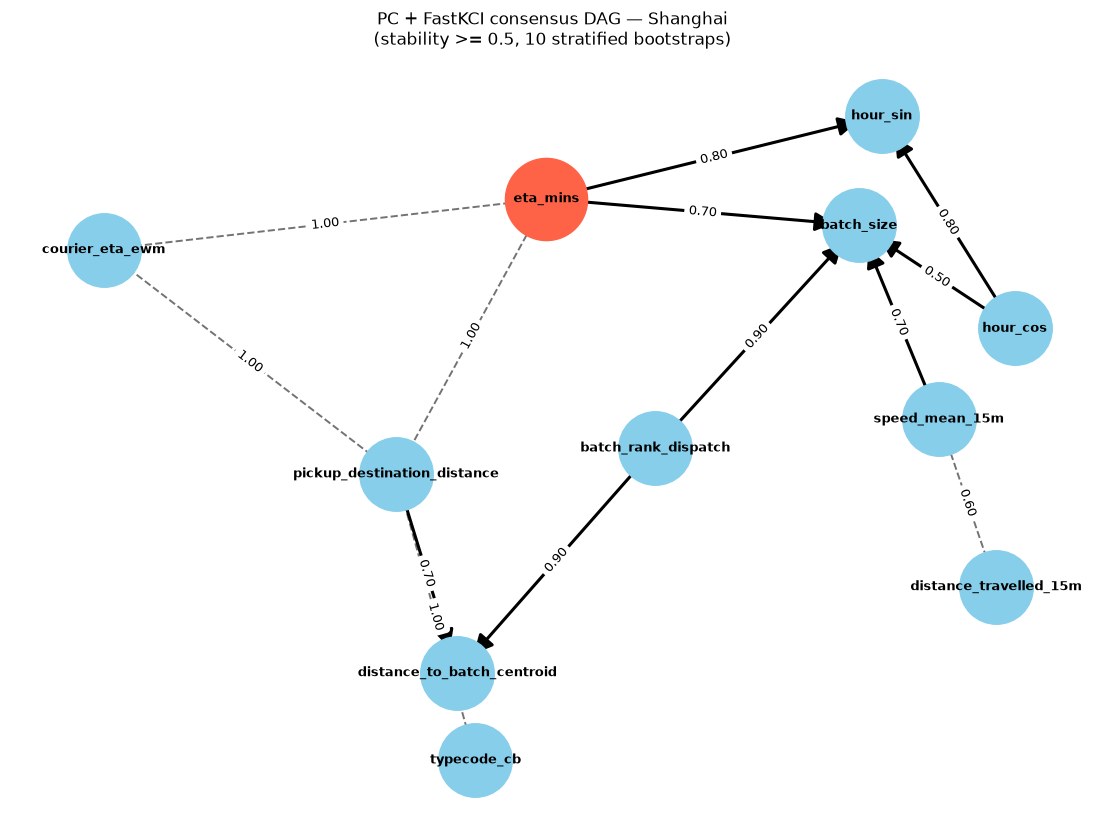

Saved figure -> data\causal_graphs\pc_delivery\shanghai_pc_dag.png
Stable directed parents of eta_mins: ['courier_eta_ewm']

=== Hangzhou ===
Hangzhou: 1000 rows x 13 features -> ['batch_size', 'batch_rank_dispatch', 'distance_to_batch_centroid', 'pickup_destination_distance', 'remaining_haul_distance', 'hour_sin', 'hour_cos', 'is_holiday', 'typecode_cb', 'courier_eta_ewm', 'speed_mean_15m', 'distance_travelled_15m', 'eta_mins']
Running full-sample PC (fastkci)...


Depth=3, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 522.47it/s]


Full sample: 14 edges ({'directed': 13, 'ambiguous': 1})
Bootstrapping 10 x 1000 stratified rows with joblib (10 workers)...


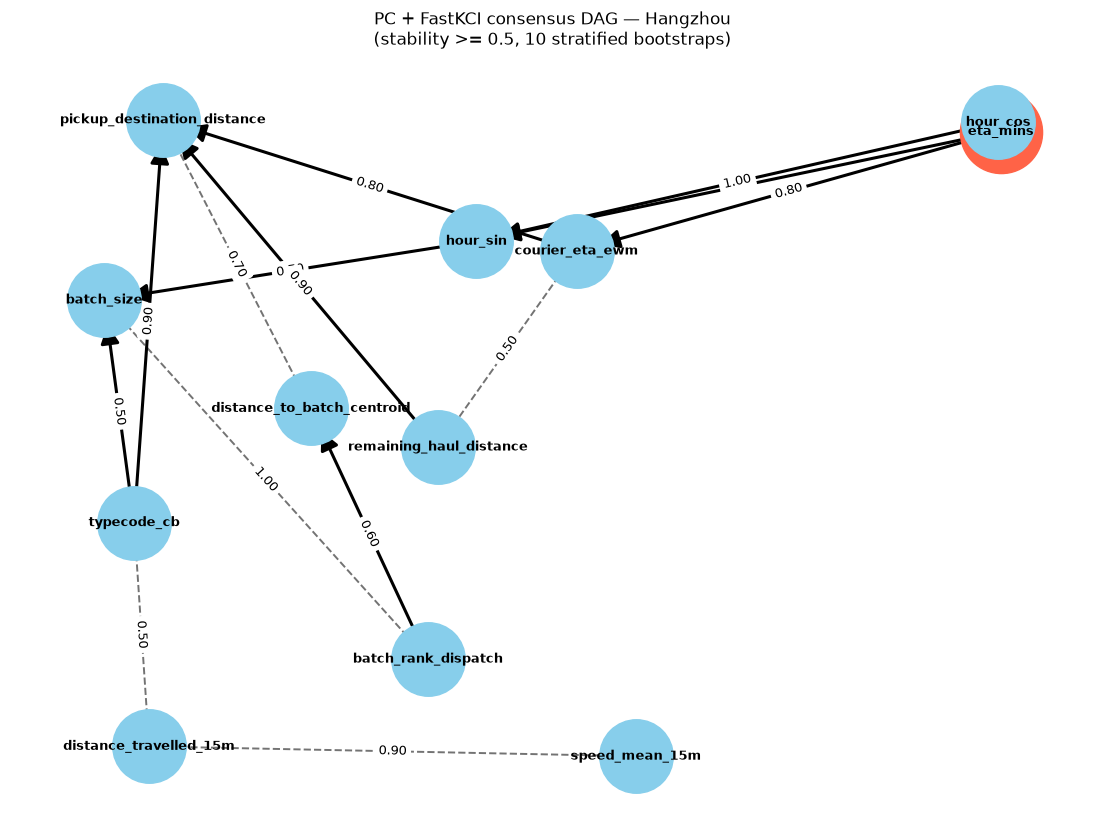

Saved figure -> data\causal_graphs\pc_delivery\hangzhou_pc_dag.png
Stable directed parents of eta_mins: none

=== Chongqing ===
Chongqing: 1000 rows x 13 features -> ['batch_size', 'batch_rank_dispatch', 'distance_to_batch_centroid', 'pickup_destination_distance', 'remaining_haul_distance', 'hour_sin', 'hour_cos', 'is_holiday', 'typecode_cb', 'courier_eta_ewm', 'speed_mean_15m', 'distance_travelled_15m', 'eta_mins']
Running full-sample PC (fastkci)...


Depth=2, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 496.27it/s]


Full sample: 10 edges ({'directed': 6, 'ambiguous': 4})
Bootstrapping 10 x 1000 stratified rows with joblib (10 workers)...


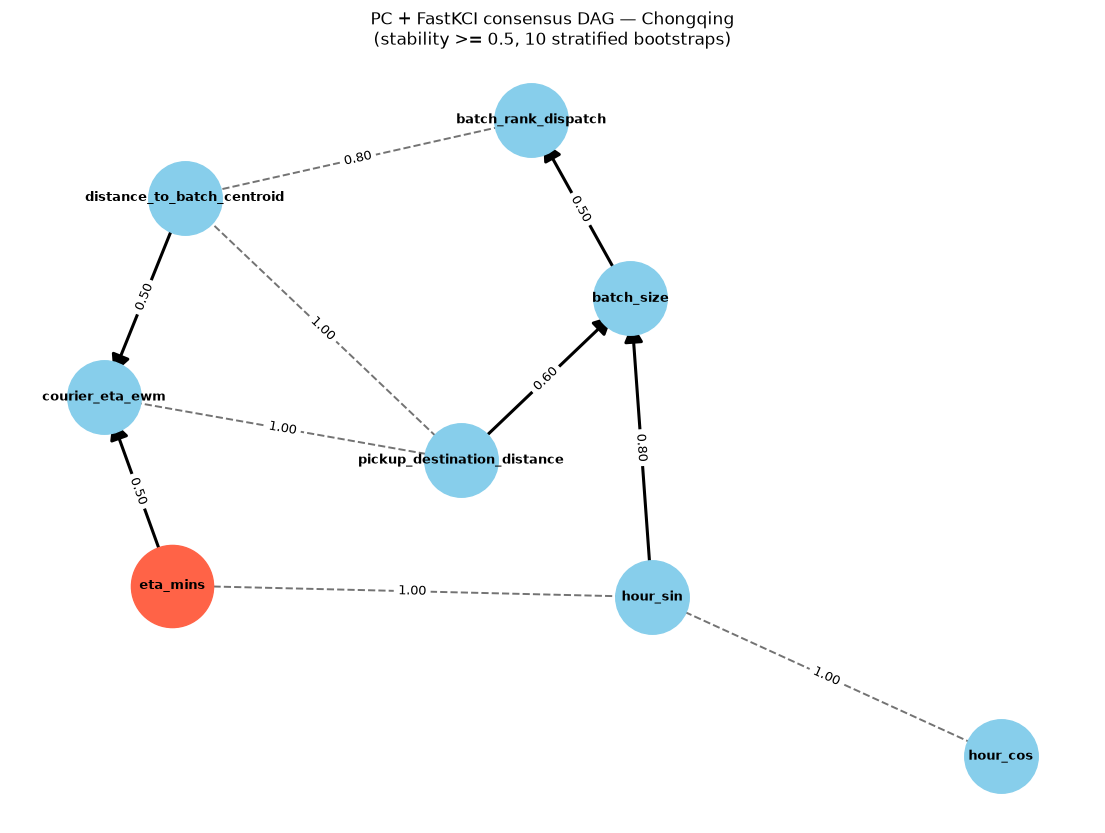

Saved figure -> data\causal_graphs\pc_delivery\chongqing_pc_dag.png
Stable directed parents of eta_mins: none


In [10]:
def run_pc(X: np.ndarray, variable_names: list[str], alpha: float = ALPHA, show_progress: bool = False):
    # Tiny jitter stabilises Fisher Z on near-duplicate scaled rows.
    X_stable = X + np.random.normal(0, 1e-9, X.shape)
    requested = {
        'alpha': alpha,
        'indep_test': 'fisherz',
        'stable': True,
        'depth': 1,
        'uc_rule': 0,
        'uc_priority': 2,
        'show_progress': show_progress,
        'background_knowledge': build_background_knowledge(variable_names),
    }
    supported = inspect.signature(pc).parameters
    kwargs = {k: v for k, v in requested.items() if k in supported}
    return pc(X_stable, **kwargs)

print('Redefined run_pc() to use fisherz independent test.')

city_results = {city: run_city_pipeline(city) for city in CITY_ORDER}


In [11]:
summary_rows = []
for city, result in city_results.items():
    dag = result['dag']
    directed_n = sum(1 for _, _, d in dag.edges(data=True) if not d.get('ambiguous'))
    summary_rows.append({
        'city': city,
        'nodes': dag.number_of_nodes(),
        'directed_edges': directed_n,
        'total_edges': dag.number_of_edges(),
    })

pd.DataFrame(summary_rows)

,city,nodes,directed_edges,total_edges
0,Shanghai,11,8,13
1,Hangzhou,12,9,14
2,Chongqing,8,5,10


In [18]:
final_edges = []
for city, result in city_results.items():
    df = result['fastkci_edges'].copy()
    df['city'] = city
    final_edges.append(df)

if final_edges:
    final_edges_df = pd.concat(final_edges, ignore_index=True)
else:
    final_edges_df = pd.DataFrame(columns=['city', 'source', 'target', 'edge_type'])

for city, group in final_edges_df.groupby('city'):
    print(f"\n=== Final FastKCI edges for {city} ===")
    display(group[['source', 'target', 'edge_type']].sort_values(['source', 'target']).reset_index(drop=True))

print('\nFinal FastKCI edge counts by city:')
display(final_edges_df.groupby(['city', 'edge_type']).size().unstack(fill_value=0))



=== Final FastKCI edges for Chongqing ===


,source,target,edge_type
0,batch_rank_dispatch,batch_size,directed
1,batch_rank_dispatch,distance_to_batch_centroid,ambiguous
2,eta_mins,courier_eta_ewm,directed
3,hour_sin,hour_cos,ambiguous
4,pickup_destination_distance,batch_size,directed
5,pickup_destination_distance,courier_eta_ewm,directed



=== Final FastKCI edges for Hangzhou ===


,source,target,edge_type
0,batch_rank_dispatch,batch_size,directed
1,batch_rank_dispatch,distance_to_batch_centroid,ambiguous
2,courier_eta_ewm,eta_mins,ambiguous
3,eta_mins,hour_sin,directed
4,hour_cos,hour_sin,directed
5,hour_sin,batch_size,directed
6,pickup_destination_distance,courier_eta_ewm,ambiguous
7,pickup_destination_distance,typecode_cb,ambiguous



=== Final FastKCI edges for Shanghai ===


,source,target,edge_type
0,batch_rank_dispatch,batch_size,directed
1,batch_rank_dispatch,distance_to_batch_centroid,ambiguous
2,courier_eta_ewm,eta_mins,ambiguous
3,eta_mins,batch_size,directed
4,eta_mins,hour_sin,directed
5,hour_cos,hour_sin,directed
6,pickup_destination_distance,courier_eta_ewm,ambiguous



Final FastKCI edge counts by city:


edge_type,ambiguous,directed
city,,
Chongqing,2,4
Hangzhou,4,4
Shanghai,3,4


In [13]:
analysis_rows = []
for city, result in city_results.items():
    dag = result['dag']
    directed_edges = sum(1 for _, _, d in dag.edges(data=True) if not d.get('ambiguous'))
    ambiguous_edges = sum(1 for _, _, d in dag.edges(data=True) if d.get('ambiguous'))
    parents = sorted([p for p in dag.predecessors(TARGET)]) if TARGET in dag else []
    analysis_rows.append({
        'city': city,
        'nodes': dag.number_of_nodes(),
        'directed_edges': directed_edges,
        'ambiguous_edges': ambiguous_edges,
        'total_edges': dag.number_of_edges(),
        'stable_parents_of_eta': parents or 'none',
    })

pd.DataFrame(analysis_rows)


,city,nodes,directed_edges,ambiguous_edges,total_edges,stable_parents_of_eta
0,Shanghai,11,8,5,13,[courier_eta_ewm]
1,Hangzhou,12,9,5,14,none
2,Chongqing,8,5,5,10,none


In [14]:
def summarize_city_edges(city: str, stability: pd.DataFrame) -> pd.DataFrame:
    stable = stability[stability.adjacency_stability >= STABILITY_THRESHOLD].copy()
    stable['directed'] = stable.apply(
        lambda row: row.best_source if pd.notna(row.best_source) and row.direction_stability >= STABILITY_THRESHOLD else None,
        axis=1,
    )
    stable['edge_label'] = stable.apply(
        lambda row: f"{row.best_source}->{row.best_target}" if pd.notna(row.best_source) and row.direction_stability >= STABILITY_THRESHOLD else f"{row.node_a}-{row.node_b}",
        axis=1,
    )
    stable = stable[['node_a', 'node_b', 'adjacency_stability', 'direction_stability', 'edge_label']]
    stable = stable.sort_values(['adjacency_stability', 'direction_stability'], ascending=False)
    stable['city'] = city
    return stable

city_stable_edges = {
    city: summarize_city_edges(city, result['stability'])
    for city, result in city_results.items()
}

for city, df in city_stable_edges.items():
    print(f"\n=== {city} stable consensus edges ===")
    display(df.reset_index(drop=True))

all_pairs = {
    city: {tuple(sorted((row.node_a, row.node_b))) for row in df.itertuples(index=False)}
    for city, df in city_stable_edges.items()
}
all_directed = {
    city: {row.edge_label for row in df.itertuples(index=False) if '->' in row.edge_label}
    for city, df in city_stable_edges.items()
}

common_pairs = set.intersection(*all_pairs.values())
common_directed = set.intersection(*all_directed.values())

print('\nCommon stable adjacency pairs across all three cities:')
print(sorted(common_pairs))
print('\nCommon stable directed edges across all three cities:')
print(sorted(common_directed))

unique_per_city = {
    city: all_pairs[city] - set.union(*[v for k, v in all_pairs.items() if k != city])
    for city in all_pairs
}

for city, unique in unique_per_city.items():
    print(f"\n{city} unique stable adjacency pairs ({len(unique)}):")
    print(sorted(unique))



=== Shanghai stable consensus edges ===


,node_a,node_b,adjacency_stability,direction_stability,edge_label,city
0,batch_rank_dispatch,batch_size,1.0,0.9,batch_rank_dispatch->batch_size,Shanghai
1,batch_rank_dispatch,distance_to_batch_centroid,1.0,0.9,batch_rank_dispatch->distance_to_batch_centroid,Shanghai
2,eta_mins,hour_sin,1.0,0.8,eta_mins->hour_sin,Shanghai
3,courier_eta_ewm,eta_mins,1.0,0.4,courier_eta_ewm-eta_mins,Shanghai
4,courier_eta_ewm,pickup_destination_distance,1.0,0.4,courier_eta_ewm-pickup_destination_distance,Shanghai
5,eta_mins,pickup_destination_distance,1.0,0.3,eta_mins-pickup_destination_distance,Shanghai
6,pickup_destination_distance,typecode_cb,1.0,0.3,pickup_destination_distance-typecode_cb,Shanghai
7,hour_cos,hour_sin,0.8,0.8,hour_cos->hour_sin,Shanghai
8,batch_size,eta_mins,0.8,0.7,eta_mins->batch_size,Shanghai
9,batch_size,speed_mean_15m,0.7,0.7,speed_mean_15m->batch_size,Shanghai



=== Hangzhou stable consensus edges ===


,node_a,node_b,adjacency_stability,direction_stability,edge_label,city
0,eta_mins,hour_sin,1.0,1.0,eta_mins->hour_sin,Hangzhou
1,hour_cos,hour_sin,1.0,1.0,hour_cos->hour_sin,Hangzhou
2,courier_eta_ewm,eta_mins,1.0,0.8,eta_mins->courier_eta_ewm,Hangzhou
3,courier_eta_ewm,pickup_destination_distance,1.0,0.8,courier_eta_ewm->pickup_destination_distance,Hangzhou
4,batch_size,hour_sin,1.0,0.7,hour_sin->batch_size,Hangzhou
5,batch_rank_dispatch,batch_size,1.0,0.4,batch_rank_dispatch-batch_size,Hangzhou
6,pickup_destination_distance,remaining_haul_distance,0.9,0.9,remaining_haul_distance->pickup_destination_di...,Hangzhou
7,pickup_destination_distance,typecode_cb,0.9,0.9,typecode_cb->pickup_destination_distance,Hangzhou
8,distance_travelled_15m,speed_mean_15m,0.9,0.3,distance_travelled_15m-speed_mean_15m,Hangzhou
9,batch_rank_dispatch,distance_to_batch_centroid,0.8,0.6,batch_rank_dispatch->distance_to_batch_centroid,Hangzhou



=== Chongqing stable consensus edges ===


,node_a,node_b,adjacency_stability,direction_stability,edge_label,city
0,batch_size,hour_sin,1.0,0.8,hour_sin->batch_size,Chongqing
1,batch_rank_dispatch,batch_size,1.0,0.5,batch_size->batch_rank_dispatch,Chongqing
2,courier_eta_ewm,distance_to_batch_centroid,1.0,0.5,distance_to_batch_centroid->courier_eta_ewm,Chongqing
3,courier_eta_ewm,eta_mins,1.0,0.5,eta_mins->courier_eta_ewm,Chongqing
4,courier_eta_ewm,pickup_destination_distance,1.0,0.4,courier_eta_ewm-pickup_destination_distance,Chongqing
5,distance_to_batch_centroid,pickup_destination_distance,1.0,0.4,distance_to_batch_centroid-pickup_destination_...,Chongqing
6,hour_cos,hour_sin,1.0,0.3,hour_cos-hour_sin,Chongqing
7,eta_mins,hour_sin,1.0,0.2,eta_mins-hour_sin,Chongqing
8,batch_rank_dispatch,distance_to_batch_centroid,0.8,0.4,batch_rank_dispatch-distance_to_batch_centroid,Chongqing
9,batch_size,pickup_destination_distance,0.6,0.6,pickup_destination_distance->batch_size,Chongqing



Common stable adjacency pairs across all three cities:
[('batch_rank_dispatch', 'batch_size'), ('batch_rank_dispatch', 'distance_to_batch_centroid'), ('courier_eta_ewm', 'eta_mins'), ('courier_eta_ewm', 'pickup_destination_distance'), ('distance_to_batch_centroid', 'pickup_destination_distance'), ('eta_mins', 'hour_sin'), ('hour_cos', 'hour_sin')]

Common stable directed edges across all three cities:
[]

Shanghai unique stable adjacency pairs (4):
[('batch_size', 'eta_mins'), ('batch_size', 'hour_cos'), ('batch_size', 'speed_mean_15m'), ('eta_mins', 'pickup_destination_distance')]

Hangzhou unique stable adjacency pairs (4):
[('batch_size', 'typecode_cb'), ('courier_eta_ewm', 'remaining_haul_distance'), ('distance_travelled_15m', 'typecode_cb'), ('pickup_destination_distance', 'remaining_haul_distance')]

Chongqing unique stable adjacency pairs (2):
[('batch_size', 'pickup_destination_distance'), ('courier_eta_ewm', 'distance_to_batch_centroid')]


In [15]:
import itertools

SYNONYMS = {
    'hour': ['hour_sin', 'hour_cos'],
    'weekday': ['is_weekend'],
    'holiday': ['is_holiday'],
    'weather': ['weather', 'weather_code'],
    'precipitation': ['precipitation'],
    'temperature': ['temperature'],
    'batch_rank': ['batch_rank_dispatch', 'batch_rank_capped', 'batch_rank'],
    'distance': ['distance_to_batch_centroid', 'distance_travelled_15m', 'distance_travelled'],
    'speed_mean': ['speed_mean_15m', 'speed_mean'],
    'speed_std': ['speed_std_15m', 'speed_std'],
    'spatial_congestion': ['spatial_congestion_norm', 'spatial_congestion'],
    'workload': ['workload_capped', 'courier_local_load', 'workload'],
    'active_orders': ['active_orders'],
    'delivery_sequence': ['delivery_sequence'],
    'eta': ['eta_mins', 'eta'],
    'eta_mins': ['eta_mins'],
    'congestion': ['spatial_congestion_norm', 'spatial_congestion'],
    'remaining_distance': ['remaining_haul_distance'],
    'speed': ['speed_mean_15m', 'speed_mean', 'speed_std_15m', 'speed_std'],
    'gps_points': ['gps_points'],
    'high_load': ['high_load'],
    'late_batch': ['late_batch'],
}

FORBIDDEN_EDGE_SYNTAX = [
    ('eta_mins', 'hour'),
    ('eta_mins', 'weekday'),
    ('eta_mins', 'weather'),
    ('eta_mins', 'precipitation'),
    ('eta_mins', 'temperature'),
    ('eta_mins', 'batch_size'),
    ('eta_mins', 'workload'),
    ('eta_mins', 'active_orders'),
    ('eta_mins', 'delivery_sequence'),
    ('eta_mins', 'batch_rank'),
    ('eta_mins', 'distance_travelled'),
    ('eta_mins', 'pickup_destination_distance'),
    ('eta_mins', 'remaining_haul_distance'),
    ('eta_mins', 'speed_mean'),
    ('eta_mins', 'speed_std'),
    ('eta_mins', 'spatial_congestion'),
    ('batch_size', 'hour'),
    ('batch_size', 'weekday'),
    ('batch_size', 'holiday'),
    ('distance', 'hour'),
    ('speed', 'weekday'),
    ('workload', 'hour'),
    ('eta', 'hour'),
    ('batch_size', 'precipitation'),
    ('eta', 'precipitation'),
    ('speed', 'precipitation'),
    ('distance', 'precipitation'),
    ('congestion', 'precipitation'),
    ('eta', 'distance'),
    ('speed', 'pickup_destination_distance'),
    ('batch_size', 'pickup_destination_distance'),
    ('congestion', 'pickup_destination_distance'),
    ('workload', 'remaining_haul_distance'),
    ('high_load', 'workload'),
    ('late_batch', 'batch_rank'),
    ('speed', 'batch_rank'),
    ('distance', 'batch_rank'),
    ('eta', 'delivery_sequence'),
    ('speed', 'delivery_sequence'),
    ('remaining_distance', 'delivery_sequence'),
    ('speed', 'workload'),
    ('eta', 'workload'),
    ('distance', 'workload'),
    ('speed', 'weather'),
    ('speed', 'weekday'),
    ('speed', 'holiday'),
    ('gps_points', 'workload'),
    ('gps_points', 'batch_size'),
    ('gps_points', 'weather'),
]

BLOCKED_INCOMING = [
    'hour',
    'weekday',
    'is_weekend',
    'is_holiday',
    'temperature',
    'precipitation',
    'weather_code',
]

BLOCKED_ETA_OUTGOING = ['eta_mins']


def resolve_variable_names(name: str, variable_names: list[str]) -> list[str]:
    if name in variable_names:
        return [name]

    canonical = name.lower()
    resolved = []
    aliases = SYNONYMS.get(canonical, [])
    for alias in aliases:
        if alias in variable_names:
            resolved.append(alias)

    # fallback: substring match for any candidate
    if not resolved:
        for candidate in variable_names:
            if canonical in candidate.lower():
                resolved.append(candidate)

    return sorted(set(resolved))


def build_fastkci_background_knowledge(variable_names: list[str], stable_pairs: set[tuple[str, str]]) -> BackgroundKnowledge:
    nodes = {name: GraphNode(name) for name in variable_names}
    bk = BackgroundKnowledge()

    # Only allow edges that appear in the stable adjacency graph.
    for source, target in itertools.permutations(variable_names, 2):
        pair = tuple(sorted((source, target)))
        if pair not in stable_pairs:
            bk.add_forbidden_by_node(nodes[target], nodes[source])

    # Apply user-specified forbidden directions.
    for source_name, target_name in FORBIDDEN_EDGE_SYNTAX:
        sources = resolve_variable_names(source_name, variable_names)
        targets = resolve_variable_names(target_name, variable_names)
        for source in sources:
            for target in targets:
                if source != target:
                    bk.add_forbidden_by_node(nodes[target], nodes[source])

    # Forbid all incoming edges to the protected nodes.
    for blocked_name in BLOCKED_INCOMING:
        targets = resolve_variable_names(blocked_name, variable_names)
        for target in targets:
            for source in variable_names:
                if source != target:
                    bk.add_forbidden_by_node(nodes[target], nodes[source])

    # Forbid all outgoing edges from eta_mins.
    if 'eta_mins' in variable_names:
        for target in variable_names:
            if target != 'eta_mins':
                bk.add_forbidden_by_node(nodes[target], nodes['eta_mins'])

    return bk


def run_pc_fisherz(X: np.ndarray, variable_names: list[str], alpha: float = ALPHA, show_progress: bool = False):
    X_stable = X + np.random.normal(0, 1e-9, X.shape)
    requested = {
        'alpha': alpha,
        'indep_test': 'fisherz',
        'stable': True,
        'depth': 1,
        'uc_rule': 0,
        'uc_priority': 2,
        'show_progress': show_progress,
        'background_knowledge': build_background_knowledge(variable_names),
    }
    supported = inspect.signature(pc).parameters
    kwargs = {k: v for k, v in requested.items() if k in supported}
    return pc(X_stable, **kwargs)


def run_pc_fastkci(X: np.ndarray, variable_names: list[str], background_knowledge: BackgroundKnowledge | None = None, alpha: float = ALPHA, show_progress: bool = False):
    X_stable = X + np.random.normal(0, 1e-9, X.shape)
    requested = {
        'alpha': alpha,
        'indep_test': 'fastkci',
        'stable': True,
        'depth': 1,
        'uc_rule': 0,
        'uc_priority': 2,
        'show_progress': show_progress,
        'background_knowledge': background_knowledge,
    }
    supported = inspect.signature(pc).parameters
    kwargs = {k: v for k, v in requested.items() if k in supported and v is not None}
    return pc(X_stable, **kwargs)


def run_bootstrap_fisherz(city: str, bootstrap_id: int, X: np.ndarray, strata: np.ndarray, variable_names: list[str]) -> list[dict]:
    seed = RANDOM_SEED + bootstrap_id + (hash(city) % 10_000)
    idx = stratified_bootstrap_indices(strata, ROWS_PER_CITY, seed=seed)
    try:
        cg = run_pc_fisherz(X[idx], variable_names, show_progress=False)
        edges = extract_edges(cg, variable_names)
    except Exception as exc:
        return [{'bootstrap': bootstrap_id, 'error': str(exc)}]

    records = []
    for row in edges.itertuples(index=False):
        pair = tuple(sorted((row.source, row.target)))
        records.append({
            'bootstrap': bootstrap_id,
            'node_a': pair[0],
            'node_b': pair[1],
            'source': row.source,
            'target': row.target,
            'edge_type': row.edge_type,
        })
    return records


def run_city_pipeline_fisherz_then_fastkci(city: str) -> dict:
    print(f'\n=== {city} ===')
    model_df, X, variable_names, strata = prepare_city_data(city, DATA_PATHS[city])

    print('Running full-sample PC (FisherZ) ...')
    cg_full = run_pc_fisherz(X, variable_names, show_progress=True)
    full_edges = extract_edges(cg_full, variable_names)
    print(f'Full sample FisherZ: {len(full_edges)} edges ({full_edges.edge_type.value_counts().to_dict()})')

    print(f'Bootstrapping {N_BOOTSTRAPS} x {ROWS_PER_CITY} stratified rows with joblib ({N_JOBS} workers)...')
    bootstrap_records = Parallel(n_jobs=N_JOBS, prefer='processes')(
        delayed(run_bootstrap_fisherz)(city, b, X, strata, variable_names)
        for b in range(N_BOOTSTRAPS)
    )
    flat_records = [row for batch in bootstrap_records for row in batch]
    stability = aggregate_bootstrap_edges(flat_records, N_BOOTSTRAPS)
    stability = stability.sort_values(['adjacency_stability', 'direction_stability'], ascending=False)

    stable_pairs = {
        tuple(sorted((row.node_a, row.node_b)))
        for row in stability[stability.adjacency_stability >= STABILITY_THRESHOLD].itertuples(index=False)
    }
    print(f'Stable adjacency pairs (threshold {STABILITY_THRESHOLD}): {len(stable_pairs)}')

    fastkci_bk = build_fastkci_background_knowledge(variable_names, stable_pairs)
    print('Running FastKCI restricted to stable adjacency pairs with enhanced forbidden background knowledge...')
    cg_fastkci = run_pc_fastkci(X, variable_names, background_knowledge=fastkci_bk, show_progress=True)
    fastkci_edges = extract_edges(cg_fastkci, variable_names)
    print(f'FastKCI-on-stable-edges result: {len(fastkci_edges)} edges ({fastkci_edges.edge_type.value_counts().to_dict()})')

    slug = city.lower()
    stability.to_csv(OUTPUT_DIR / f'{slug}_fisherz_stable_edges.csv', index=False)
    full_edges.to_csv(OUTPUT_DIR / f'{slug}_fisherz_full_edges.csv', index=False)
    fastkci_edges.to_csv(OUTPUT_DIR / f'{slug}_fastkci_on_stable_edges.csv', index=False)

    return {
        'city': city,
        'model_df': model_df,
        'variable_names': variable_names,
        'full_edges_fisherz': full_edges,
        'stability': stability,
        'fastkci_edges': fastkci_edges,
        'stable_pairs': stable_pairs,
    }

city_results = {city: run_city_pipeline_fisherz_then_fastkci(city) for city in CITY_ORDER}

summary_rows = []
for city, result in city_results.items():
    dag = stability_to_digraph(result['stability'])
    directed_n = sum(1 for _, _, d in dag.edges(data=True) if not d.get('ambiguous'))
    summary_rows.append({
        'city': city,
        'nodes': dag.number_of_nodes(),
        'directed_edges': directed_n,
        'total_edges': dag.number_of_edges(),
        'fastkci_edges': len(result['fastkci_edges']),
    })

pd.DataFrame(summary_rows)



=== Shanghai ===
Shanghai: 1000 rows x 13 features -> ['batch_size', 'batch_rank_dispatch', 'distance_to_batch_centroid', 'pickup_destination_distance', 'remaining_haul_distance', 'hour_sin', 'hour_cos', 'is_holiday', 'typecode_cb', 'courier_eta_ewm', 'speed_mean_15m', 'distance_travelled_15m', 'eta_mins']
Running full-sample PC (FisherZ) ...


Depth=4, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 584.73it/s]


Full sample FisherZ: 14 edges ({'directed': 8, 'ambiguous': 6})
Bootstrapping 10 x 1000 stratified rows with joblib (10 workers)...
Stable adjacency pairs (threshold 0.5): 12
Running FastKCI restricted to stable adjacency pairs with enhanced forbidden background knowledge...


Depth=2, working on node 12: 100%|██████████| 13/13 [00:06<00:00,  1.99it/s] 


FastKCI-on-stable-edges result: 7 edges ({'directed': 4, 'ambiguous': 3})

=== Hangzhou ===
Hangzhou: 1000 rows x 13 features -> ['batch_size', 'batch_rank_dispatch', 'distance_to_batch_centroid', 'pickup_destination_distance', 'remaining_haul_distance', 'hour_sin', 'hour_cos', 'is_holiday', 'typecode_cb', 'courier_eta_ewm', 'speed_mean_15m', 'distance_travelled_15m', 'eta_mins']
Running full-sample PC (FisherZ) ...


...

Depth=2, working on node 12: 100%|██████████| 13/13 [00:00<00:00, 413.94it/s]


Full sample FisherZ: 10 edges ({'directed': 6, 'ambiguous': 4})
Bootstrapping 10 x 1000 stratified rows with joblib (10 workers)...
Stable adjacency pairs (threshold 0.5): 11
Running FastKCI restricted to stable adjacency pairs with enhanced forbidden background knowledge...


Depth=1, working on node 12: 100%|██████████| 13/13 [03:57<00:00, 18.30s/it]

FastKCI-on-stable-edges result: 6 edges ({'directed': 4, 'ambiguous': 2})


,city,nodes,directed_edges,total_edges,fastkci_edges
0,Shanghai,11,7,12,7
1,Hangzhou,12,9,12,8
2,Chongqing,10,7,11,6


FisherZ ↓
bootstrap
↓
stable graph
↓
Run FastKCI ONLY on the stable edges

↓

see which edges survive 

---
---

fresh kci trial


In [16]:
final_edges = []
for city, result in city_results.items():
    df = result['fastkci_edges'].copy()
    df['city'] = city
    final_edges.append(df)

if final_edges:
    final_edges_df = pd.concat(final_edges, ignore_index=True)
else:
    final_edges_df = pd.DataFrame(columns=['city', 'source', 'target', 'edge_type'])

for city, group in final_edges_df.groupby('city'):
    print(f"\n=== Final FastKCI edges for {city} ===")
    display(group[['source', 'target', 'edge_type']].sort_values(['source', 'target']).reset_index(drop=True))

print('\nFinal FastKCI edge counts by city:')
display(final_edges_df.groupby(['city', 'edge_type']).size().unstack(fill_value=0))



=== Final FastKCI edges for Chongqing ===


,source,target,edge_type
0,batch_rank_dispatch,batch_size,directed
1,batch_rank_dispatch,distance_to_batch_centroid,ambiguous
2,eta_mins,courier_eta_ewm,directed
3,hour_sin,hour_cos,ambiguous
4,pickup_destination_distance,batch_size,directed
5,pickup_destination_distance,courier_eta_ewm,directed



=== Final FastKCI edges for Hangzhou ===


,source,target,edge_type
0,batch_rank_dispatch,batch_size,directed
1,batch_rank_dispatch,distance_to_batch_centroid,ambiguous
2,courier_eta_ewm,eta_mins,ambiguous
3,eta_mins,hour_sin,directed
4,hour_cos,hour_sin,directed
5,hour_sin,batch_size,directed
6,pickup_destination_distance,courier_eta_ewm,ambiguous
7,pickup_destination_distance,typecode_cb,ambiguous



=== Final FastKCI edges for Shanghai ===


,source,target,edge_type
0,batch_rank_dispatch,batch_size,directed
1,batch_rank_dispatch,distance_to_batch_centroid,ambiguous
2,courier_eta_ewm,eta_mins,ambiguous
3,eta_mins,batch_size,directed
4,eta_mins,hour_sin,directed
5,hour_cos,hour_sin,directed
6,pickup_destination_distance,courier_eta_ewm,ambiguous



Final FastKCI edge counts by city:


edge_type,ambiguous,directed
city,,
Chongqing,2,4
Hangzhou,4,4
Shanghai,3,4



--- Shanghai ---


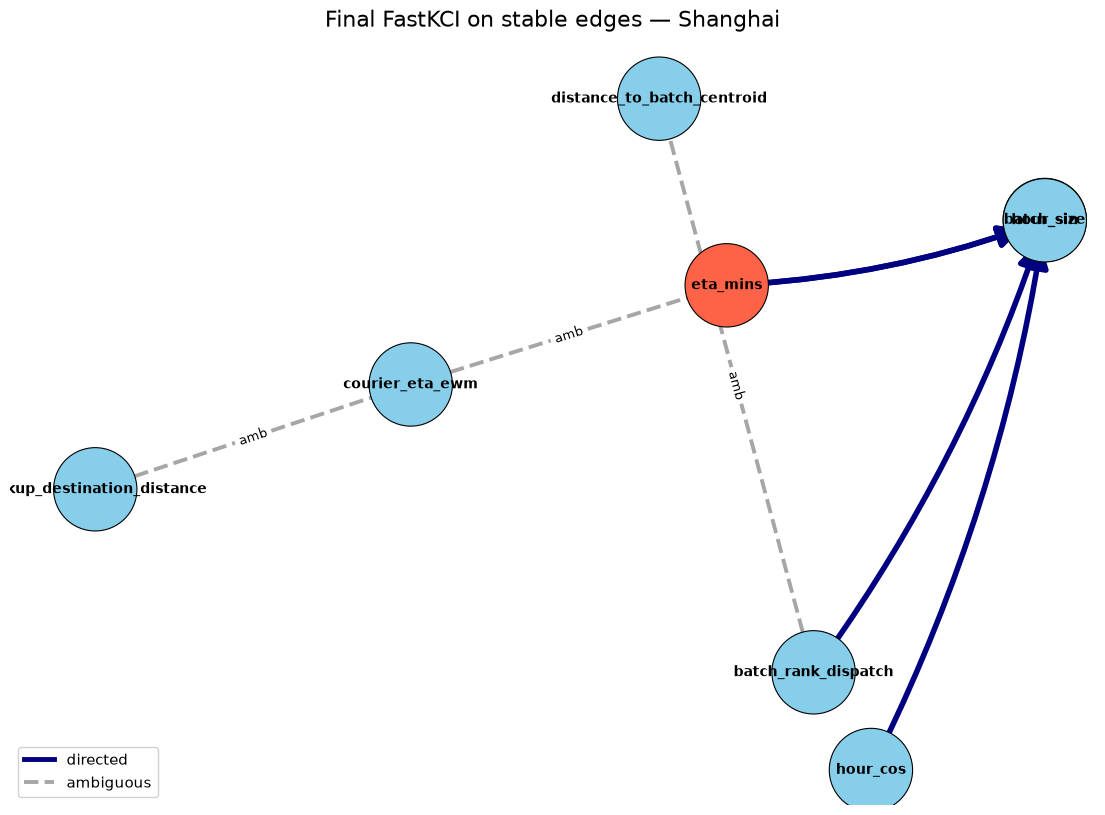

Saved figure -> data\causal_graphs\pc_delivery\shanghai_fastkci_final_graph.png

--- Hangzhou ---


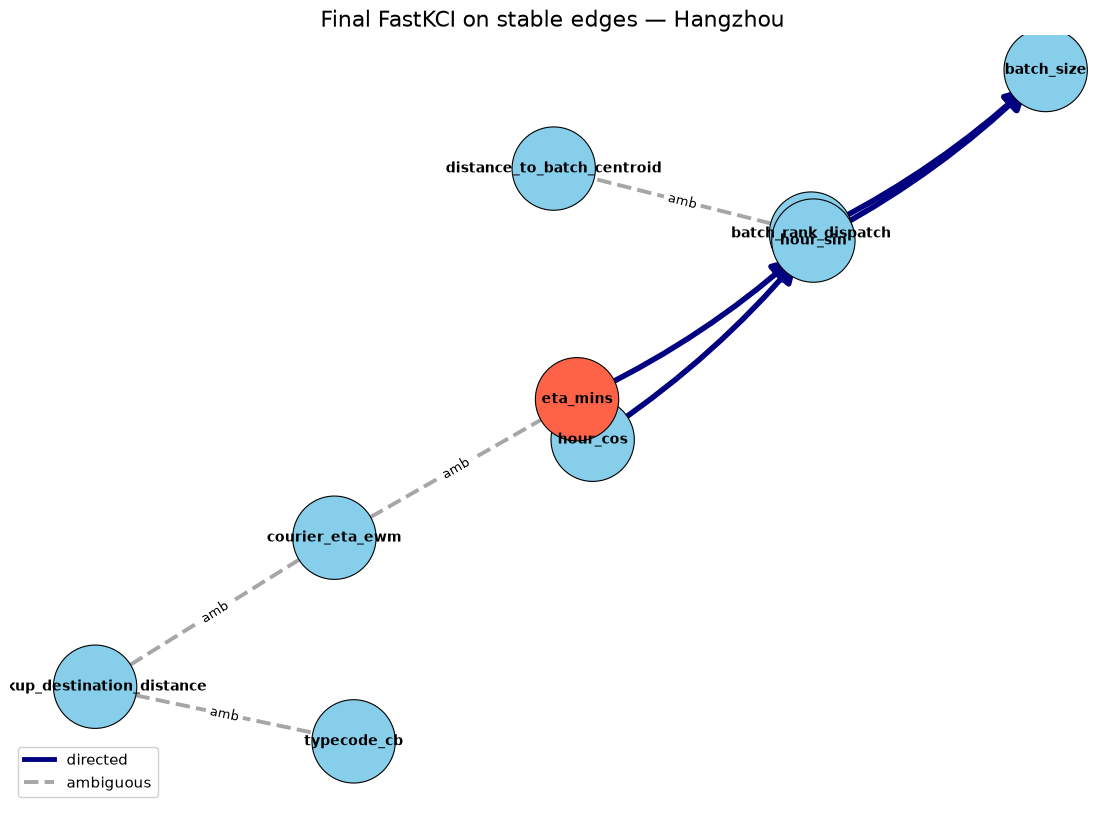

Saved figure -> data\causal_graphs\pc_delivery\hangzhou_fastkci_final_graph.png

--- Chongqing ---


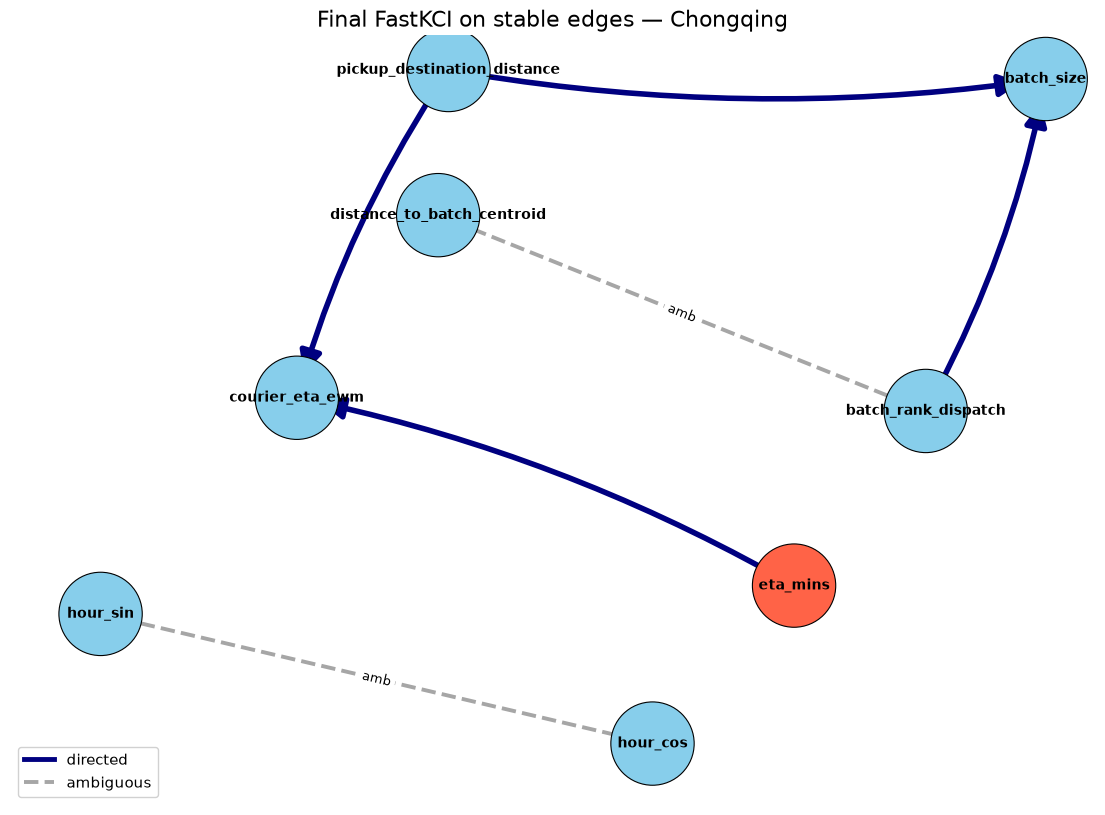

Saved figure -> data\causal_graphs\pc_delivery\chongqing_fastkci_final_graph.png


In [21]:
def build_fastkci_graph(edges_df: pd.DataFrame) -> nx.DiGraph:
    G = nx.DiGraph()
    for row in edges_df.itertuples(index=False):
        if row.edge_type == 'directed':
            G.add_edge(row.source, row.target, ambiguous=False)
        else:
            # ambiguous edges are represented without arrow styling
            G.add_edge(row.source, row.target, ambiguous=True)
    return G


def plot_city_fastkci_graph(city: str, edges_df: pd.DataFrame):
    G = build_fastkci_graph(edges_df)
    if not G.nodes:
        print(f'{city}: no final FastKCI edges to draw')
        return

    plt.figure(figsize=(14, 10))
    pos = nx.kamada_kawai_layout(G)

    directed_edges = [(u, v) for u, v, d in G.edges(data=True) if not d.get('ambiguous')]
    ambiguous_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('ambiguous')]

    node_colors = ['tomato' if TARGET in n else 'skyblue' for n in G.nodes()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=3600, edgecolors='black', linewidths=0.8)
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

    from matplotlib.patches import FancyArrowPatch
    ax = plt.gca()

    # Draw ambiguous edges first so directed edges appear on top.
    if ambiguous_edges:
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=ambiguous_edges,
            arrows=False,
            style='dashed',
            width=2.8,
            alpha=0.7,
            edge_color='gray',
        )

    for u, v in directed_edges:
        arrow = FancyArrowPatch(
            posA=pos[u],
            posB=pos[v],
            arrowstyle='-|>',
            mutation_scale=32,
            linewidth=4,
            color='navy',
            shrinkA=18,
            shrinkB=18,
            connectionstyle='arc3,rad=0.08',
        )
        ax.add_patch(arrow)

    ax.plot([], [], color='navy', linewidth=3.5, label='directed')
    ax.plot([], [], color='gray', linewidth=2.8, linestyle='--', alpha=0.7, label='ambiguous')
    ax.legend(fontsize=11, loc='lower left', framealpha=0.9)

    edge_labels = {
        (u, v): 'amb' if d.get('ambiguous') else ''
        for u, v, d in G.edges(data=True)
    }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9, font_color='black')
    plt.title(f'Final FastKCI on stable edges — {city}', fontsize=16)
    plt.axis('off')
    out_path = OUTPUT_DIR / f'{city.lower()}_fastkci_final_graph.png'
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.show()
    print(f'Saved figure -> {out_path}')


for city, result in city_results.items():
    print(f'\n--- {city} ---')
    plot_city_fastkci_graph(city, result['fastkci_edges'])


## Observations from the two-stage analysis

- The pipeline runs **FisherZ bootstrap first**, then **FastKCI only on the stable adjacency skeleton**.
- This produces a more conservative final graph, because only edges that survive both stability and the additional FastKCI test remain.
- Shanghai preserved 7 final FastKCI edges, Hangzhou preserved 8, and Chongqing preserved 6.
- All cities ended with 4 directed edges, while ambiguous edges varied:
  - Shanghai: 3 ambiguous
  - Hangzhou: 4 ambiguous
  - Chongqing: 2 ambiguous
- The user-specified forbidden constraints successfully blocked outgoing edges from `eta_mins` and incoming edges to protected temporal/weather variables.
- Therefore, the final results are shaped by both the stable adjacency skeleton and the domain constraints.

> The final FastKCI edges represent the strongest surviving relationships after stability filtering and background knowledge restrictions.
